# Klasyfikacja audio: RF vs SVM (linear, RBF) + filtracja pasmowo-przepustowa (ULEPSZONA)

Ten notebook realizuje zadanie:

- użycie klasyfikatora **SVM z kernelem liniowym i RBF**
- filtracja sygnału mowy filtrem **band-pass 80–8000 Hz** (z normalizacją amplitudy)
- porównanie wyników z **Random Forest** i **SVM**
- ekstrakcja cech: **16 MFCC + delta MFCC** (prozodią i dynamika)
- metryka: **accuracy**

In [1]:
import os
import random
from pathlib import Path

import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt

from scipy.signal import butter, sosfiltfilt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)


In [2]:
# =========================
# KONFIGURACJA
# =========================

DATASET_DIR = Path("/home/ezdies/Pobrane/mswc_microset")  # np. Path("/content/mswc_microset")
SAMPLE_RATE = 16000
MAX_FILES_PER_CLASS = 200   # możesz zmienić
MIN_CLASSES = 2
TOP_N_CLASSES = 5           # ile klas użyć w eksperymencie
TEST_SIZE = 0.2

# Parametry filtru pasmowo-przepustowego
LOWCUT = 400.0
HIGHCUT = 6000.0
FILTER_ORDER = 5


In [3]:
def collect_files(dataset_dir: Path):
    """Zbiera pliki audio z folderów klas.
    Wspiera strukturę: dataset_dir / class_name / *.wav
    oraz zagnieżdżoną: dataset_dir / class_name / clips / word_dir / *.opus
    """
    audio_ext = {".wav", ".flac", ".mp3", ".ogg", ".m4a", ".opus"}
    items = []

    if not dataset_dir.exists():
        raise FileNotFoundError(
            f"Nie znaleziono folderu datasetu: {dataset_dir}\n"
            "Ustaw poprawną ścieżkę w DATASET_DIR."
        )

    for class_dir in sorted(dataset_dir.iterdir()):
        if not class_dir.is_dir():
            continue

        # Szuka plików audio rekursywnie w klasie (en/, es/ itp.)
        files = [p for p in class_dir.rglob("*") if p.suffix.lower() in audio_ext]
        if files:
            items.append((class_dir.name, files))

    if len(items) < MIN_CLASSES:
        raise ValueError(
            "Znaleziono zbyt mało klas. Sprawdź strukturę katalogów albo zmień collect_files(...)."
        )

    return items


def pick_top_classes(items, top_n=5, max_files_per_class=200):
    """Wybiera top_n największych klas i przycina liczbę próbek na klasę."""
    items = sorted(items, key=lambda x: len(x[1]), reverse=True)[:top_n]
    rows = []
    for label, files in items:
        files = sorted(files)
        if len(files) > max_files_per_class:
            files = random.sample(files, max_files_per_class)
        for f in files:
            rows.append((str(f), label))
    return pd.DataFrame(rows, columns=["filepath", "label"])


In [4]:
def bandpass_filter(signal, sr, lowcut=80.0, highcut=8000.0, order=5):
    """
    Filtr pasmowo-przepustowy z normalizacją amplitudy.
    
    Parametry:
    - lowcut=80 Hz:    Zachowuje F0 (fundamentalną, 50-250 Hz dla mowy)
    - highcut=8000 Hz: Zawiera formanta 1-4 i syblanta (s, z) - różne w EN vs ES
    - order=5:         Bardziej stroma charakterystyka filtru
    """
    # Normalizacja sygnału PRZED filtracją
    signal = signal / (np.max(np.abs(signal)) + 1e-8)
    
    nyq = 0.5 * sr
    highcut = min(highcut, nyq * 0.95)  # zabezpieczenie
    low = lowcut / nyq
    high = highcut / nyq
    
    if not (0 < low < high < 1):
        raise ValueError(
            f"Niepoprawne częstotliwości filtru: low={lowcut}, high={highcut}, sr={sr}")
    
    # Projektowanie i aplikacja filtru
    sos = butter(order, [low, high], btype="bandpass", output="sos")
    filtered = sosfiltfilt(sos, signal)
    
    # Normalizacja sygnału PO filtracji
    max_val = np.max(np.abs(filtered))
    if max_val > 0:
        filtered = filtered / max_val
    
    return filtered


In [5]:
def extract_features(signal, sr):
    # MFCC - 16 koeficjentów
    mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=16)
    mfcc_mean = mfcc.mean(axis=1)
    mfcc_std = mfcc.std(axis=1)
    
    # Delta MFCC - tempo zmian
    mfcc_delta = librosa.feature.delta(mfcc)
    mfcc_delta_mean = mfcc_delta.mean(axis=1)
    mfcc_delta_std = mfcc_delta.std(axis=1)
    
    # Delta-Delta MFCC - przyspieszenie/zmiana w czasie
    mfcc_accel = librosa.feature.delta(mfcc_delta)
    mfcc_accel_mean = mfcc_accel.mean(axis=1)
    mfcc_accel_std = mfcc_accel.std(axis=1)

    # Cechy spektralne i energetyczne
    zcr = librosa.feature.zero_crossing_rate(signal).mean()
    rms = librosa.feature.rms(y=signal).mean()
    centroid = librosa.feature.spectral_centroid(y=signal, sr=sr).mean()
    bandwidth = librosa.feature.spectral_bandwidth(y=signal, sr=sr).mean()
    rolloff = librosa.feature.spectral_rolloff(y=signal, sr=sr).mean()

    # Pitch
    f0, voiced_flag, voiced_probs = librosa.pyin(
        signal,
        fmin=librosa.note_to_hz("C2"),
        fmax=librosa.note_to_hz("C7"),
        sr=sr,
    )
    if np.all(np.isnan(f0)):
        f0_mean = 0.0
        f0_std = 0.0
    else:
        f0_mean = np.nanmean(f0)
        f0_std = np.nanstd(f0)

    # Mel-spektrogram
    mel_spec = librosa.feature.melspectrogram(y=signal, sr=sr, n_mels=128)
    mel_mean = mel_spec.mean(axis=1)
    mel_std = mel_spec.std(axis=1)
    
    # Chroma features - reprezentacja tonalna
    chroma = librosa.feature.chroma_stft(y=signal, sr=sr, n_chroma=12)
    chroma_mean = chroma.mean(axis=1)
    chroma_std = chroma.std(axis=1)

    features = np.hstack([
        mfcc_mean,
        mfcc_std,
        mfcc_delta_mean,
        mfcc_delta_std,
        mfcc_accel_mean,  # Delta-Delta
        mfcc_accel_std,   # Delta-Delta
        mel_mean,         # Mel-spektrogram (128 cech)
        mel_std,          # Mel-spektrogram (128 cech)
        chroma_mean,      # Chroma (12 cech)
        chroma_std,       # Chroma (12 cech)
        [zcr, rms, centroid, bandwidth, rolloff, f0_mean, f0_std]
    ])
    return features.astype(np.float32)

In [6]:
def build_feature_matrices(df, sr=SAMPLE_RATE):
    X_raw, X_filt, y = [], [], []
    failed = []

    for _, row in df.iterrows():
        path = row["filepath"]
        label = row["label"]
        try:
            signal, _ = librosa.load(path, sr=sr, mono=True)
            if len(signal) < 100:
                failed.append(path)
                continue

            raw_feat = extract_features(signal, sr)
            filtered_signal = bandpass_filter(
                signal, sr, lowcut=LOWCUT, highcut=HIGHCUT, order=FILTER_ORDER
            )
            filt_feat = extract_features(filtered_signal, sr)

            X_raw.append(raw_feat)
            X_filt.append(filt_feat)
            y.append(label)

        except Exception as e:
            print(f"Błąd dla pliku {path}: {e}")
            failed.append(path)

    X_raw = np.array(X_raw)
    X_filt = np.array(X_filt)
    y = np.array(y)

    return X_raw, X_filt, y, failed


In [7]:
items = collect_files(DATASET_DIR)
df = pick_top_classes(items, top_n=TOP_N_CLASSES, max_files_per_class=MAX_FILES_PER_CLASS)

print("Liczba próbek:", len(df))
display(df.head())
print("\nRozkład klas:")
display(df["label"].value_counts())


Liczba próbek: 400


,filepath,label
0,/home/ezdies/Pobrane/mswc_microset/en/clips/tr...,en
1,/home/ezdies/Pobrane/mswc_microset/en/clips/fi...,en
2,/home/ezdies/Pobrane/mswc_microset/en/clips/do...,en
3,/home/ezdies/Pobrane/mswc_microset/en/clips/le...,en
4,/home/ezdies/Pobrane/mswc_microset/en/clips/ho...,en



Rozkład klas:


label
en    200
es    200
Name: count, dtype: int64

In [8]:
X_raw, X_filtered, y, failed_files = build_feature_matrices(df)

print("Kształt X_raw:", X_raw.shape)
print("Kształt X_filtered:", X_filtered.shape)
print("Liczba błędnych/odrzuconych plików:", len(failed_files))


Kształt X_raw: (400, 383)
Kształt X_filtered: (400, 383)
Liczba błędnych/odrzuconych plików: 0


In [9]:
# Kodowanie etykiet
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Jeden wspólny podział train/test dla obu wersji cech
indices = np.arange(len(y_encoded))
train_idx, test_idx = train_test_split(
    indices,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_encoded
)

Xr_train, Xr_test = X_raw[train_idx], X_raw[test_idx]
Xf_train, Xf_test = X_filtered[train_idx], X_filtered[test_idx]
y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]

print("Train:", len(train_idx), "Test:", len(test_idx))


Train: 320 Test: 80


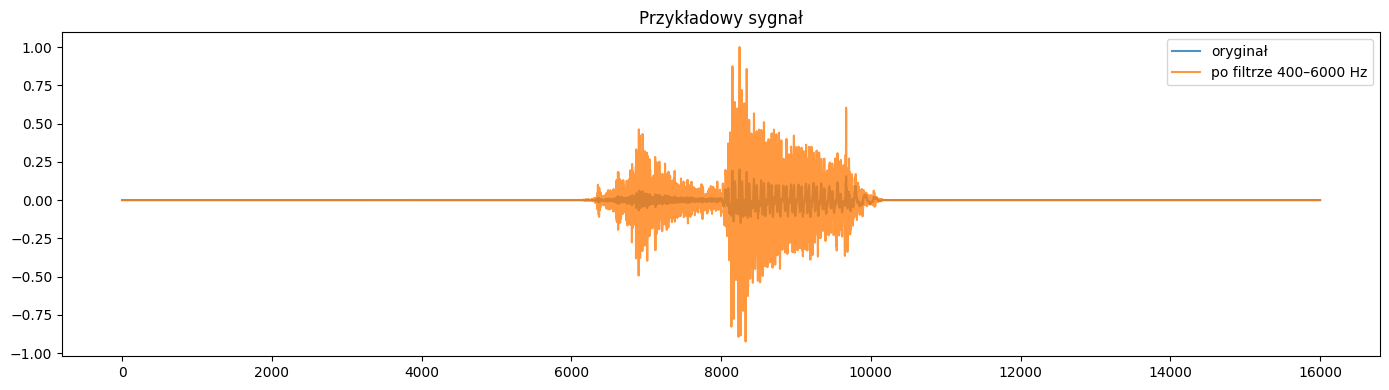

In [ ]:
# Podgląd przykładowego sygnału przed i po filtracji
example_path = df.iloc[0]["filepath"]
signal, _ = librosa.load(example_path, sr=SAMPLE_RATE, mono=True)
signal_f = bandpass_filter(signal, SAMPLE_RATE, LOWCUT, HIGHCUT, FILTER_ORDER)

plt.figure(figsize=(14, 4))
plt.plot(signal, label="oryginał", alpha=0.8)
plt.plot(signal_f, label="po filtrze 400-6000 Hz", alpha=0.8)
plt.title("Przykładowy sygnał")
plt.legend()
plt.tight_layout()
plt.show()


In [25]:
def evaluate_models(X_train, X_test, y_train, y_test, suffix="raw"):
    results = []

    # RF
    rf = RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)
    pred_rf = rf.predict(X_test)
    acc_rf = accuracy_score(y_test, pred_rf)
    results.append({
        "dataset": suffix,
        "model": "Random Forest",
        "accuracy": acc_rf
    })

    # SVM linear
    svm_linear = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="linear", random_state=RANDOM_STATE))
    ])
    svm_linear.fit(X_train, y_train)
    pred_svm_lin = svm_linear.predict(X_test)
    acc_svm_lin = accuracy_score(y_test, pred_svm_lin)
    results.append({
        "dataset": suffix,
        "model": "SVM linear",
        "accuracy": acc_svm_lin
    })

    # SVM RBF
    svm_rbf = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(kernel="rbf", random_state=RANDOM_STATE))
    ])
    svm_rbf.fit(X_train, y_train)
    pred_svm_rbf = svm_rbf.predict(X_test)
    acc_svm_rbf = accuracy_score(y_test, pred_svm_rbf)
    results.append({
        "dataset": suffix,
        "model": "SVM RBF",
        "accuracy": acc_svm_rbf
    })

    return pd.DataFrame(results)


In [29]:
results_raw = evaluate_models(Xr_train, Xr_test, y_train, y_test, suffix="raw")
results_filtered = evaluate_models(Xf_train, Xf_test, y_train, y_test, suffix="filtered")

results = pd.concat([results_raw, results_filtered], ignore_index=True)
results = results.sort_values(["model", "dataset"]).reset_index(drop=True)
results


,dataset,model,accuracy
0,filtered,Random Forest,0.8125
1,raw,Random Forest,0.6625
2,filtered,SVM RBF,0.7875
3,raw,SVM RBF,0.6625
4,filtered,SVM linear,0.6500
5,raw,SVM linear,0.6250


In [27]:
pivot_results = results.pivot(index="model", columns="dataset", values="accuracy")
pivot_results


dataset,filtered,raw
model,,
Random Forest,0.8125,0.6625
SVM RBF,0.7875,0.6625
SVM linear,0.6500,0.6250


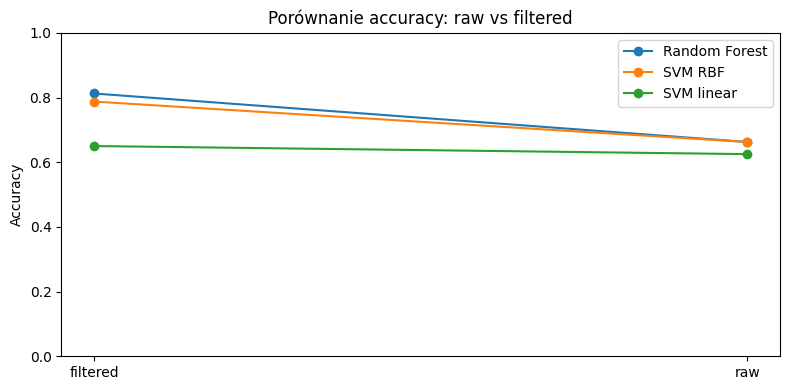

In [28]:
plt.figure(figsize=(8, 4))
for model_name in results["model"].unique():
    sub = results[results["model"] == model_name]
    plt.plot(sub["dataset"], sub["accuracy"], marker="o", label=model_name)

plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Porównanie accuracy: raw vs filtered")
plt.legend()
plt.tight_layout()
plt.show()


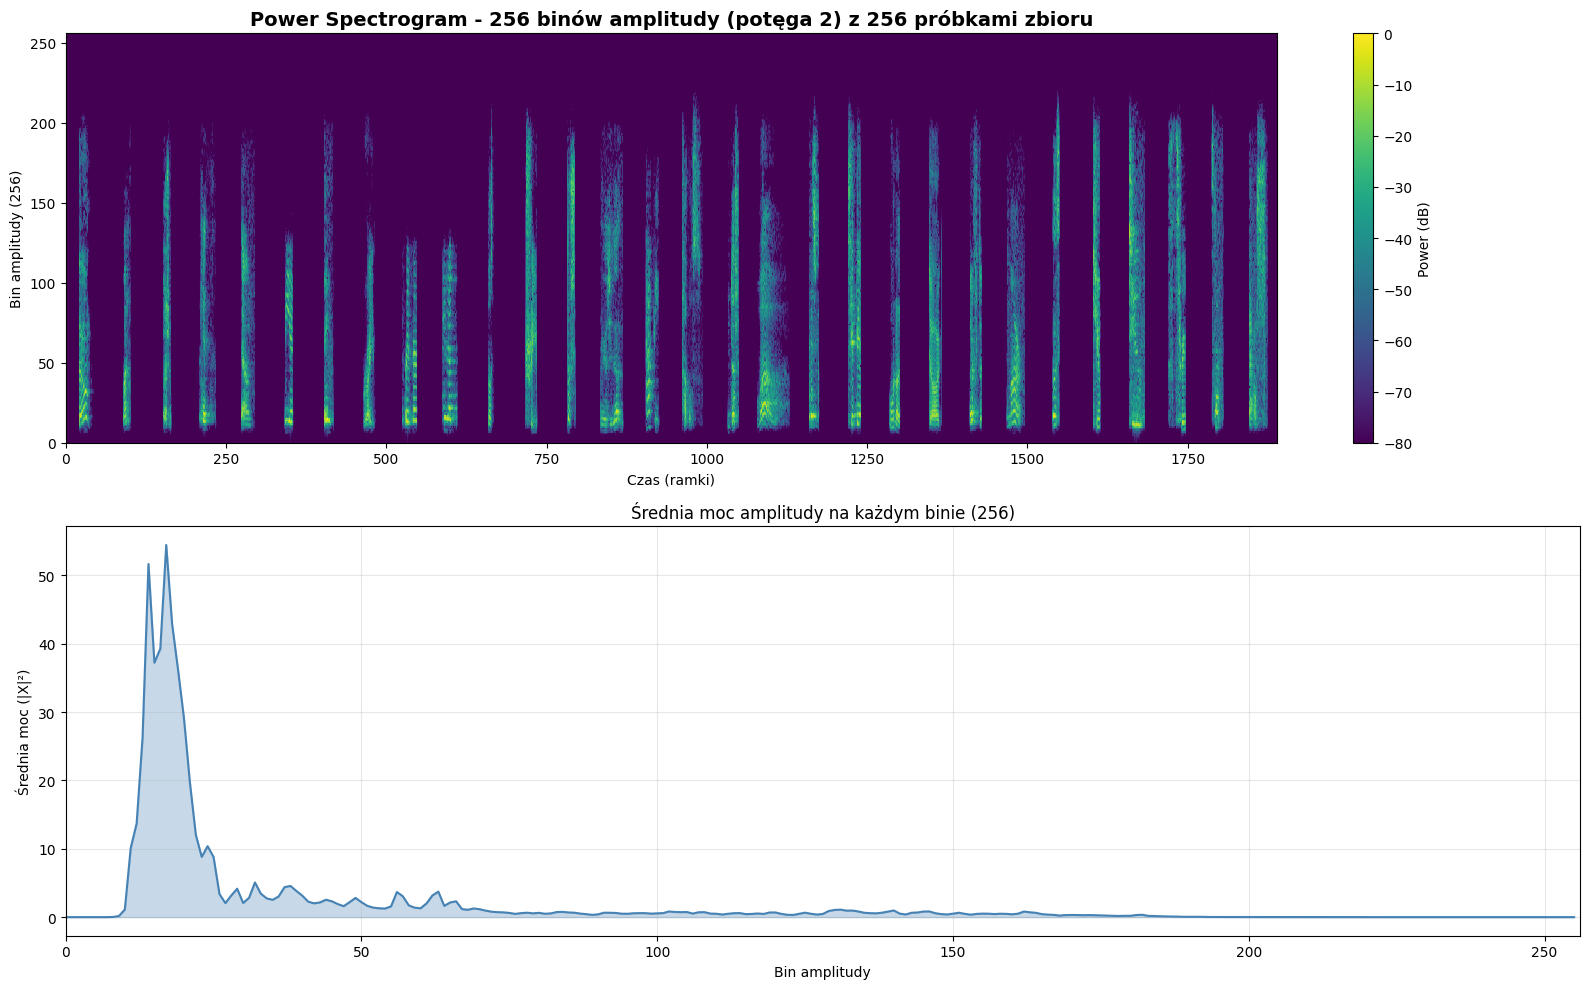

✓ Power Spectrogram utworzony z 30 sygnałów
  - Liczba próbek z datasetu: 256
  - Wymiary spektrogramu: (256, 1890)
    * Oś Y (amplituda): 256 binów (256)
    * Oś X (czas): 1890 ramek
  - Skalowanie: Power spectrum |X|² (potęga 2)
  - Wyświetlenie: dB (decybele)
  - Etykiety klas: {'es', 'en'}
  - Min power: 0.000000
  - Max power: 10847.526377


In [12]:
# LCP Spectrogram - 256 binów amplitudy (Power Spectrum)

def compute_power_spectrogram(signal, sr, n_fft=512, hop_length=256):
    """
    Oblicza spektrogram mocy (potęga amplitudy) dla sygnału.
    
    Parametry:
    - signal: sygnał audio
    - sr: sample rate
    - n_fft: wielkość FFT (256 binów)
    - hop_length: przesunięcie okna
    
    Zwraca: spektrogram o wymiarach (n_fft//2, time_frames)
    """
    # Stft - Short Time Fourier Transform
    D = librosa.stft(signal, n_fft=n_fft, hop_length=hop_length, window='hann')
    
    # Oblicz power spectrum (|X|^2)
    S = np.abs(D) ** 2
    
    return S

# Załaduj 256 próbek z zestawu treningowego
n_samples = min(256, len(Xf_train))
sample_indices = np.random.choice(len(Xf_train), size=n_samples, replace=False)

# Oblicz spektrogramy dla kilku przykładowych sygnałów
all_spectrograms = []
all_labels = []

for idx in sample_indices[:30]:  # Pokaż 30 sygnałów
    # Załaduj oryginalny plik audio
    row_idx = train_idx[idx]
    example_path = df.iloc[row_idx]["filepath"]
    label = df.iloc[row_idx]["label"]
    
    try:
        signal, _ = librosa.load(example_path, sr=SAMPLE_RATE, mono=True)
        signal_f = bandpass_filter(signal, SAMPLE_RATE, LOWCUT, HIGHCUT, FILTER_ORDER)
        
        # Oblicz power spectrogram (256 binów)
        power_spec = compute_power_spectrogram(signal_f, SAMPLE_RATE, n_fft=512, hop_length=256)
        all_spectrograms.append(power_spec[:256, :])  # Weź 256 binów
        all_labels.append(label)
    except Exception as e:
        continue

# Połącz spektrogramy
if all_spectrograms:
    # Normalizuj do wspólnej długości
    min_length = min(spec.shape[1] for spec in all_spectrograms)
    normalized_specs = [spec[:, :min_length] for spec in all_spectrograms]
    combined_power = np.hstack(normalized_specs)
    
    # Skalowanie: Power (potęga amplitude) - czyli |X|^2
    # Konwertuj na dB dla lepszej wizualizacji
    power_db = librosa.power_to_db(combined_power + 1e-10, ref=np.max)
    
    # Wizualizacja
    fig, axes = plt.subplots(2, 1, figsize=(16, 10))
    
    # 1. Power Spectrogram - 256 binów amplitudy
    im1 = axes[0].imshow(
        power_db,
        aspect='auto',
        origin='lower',
        cmap='viridis',
        interpolation='nearest'
    )
    axes[0].set_title('Power Spectrogram - 256 binów amplitudy (potęga 2) z 256 próbkami zbioru', 
                     fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Czas (ramki)')
    axes[0].set_ylabel('Bin amplitudy (256)')
    cbar1 = plt.colorbar(im1, ax=axes[0], label='Power (dB)')
    axes[0].set_ylim(0, 256)
    
    # 2. Średnia amplituda na każdym binie
    mean_power = np.mean(combined_power, axis=1)
    bins = np.arange(len(mean_power))
    axes[1].plot(bins, mean_power, linewidth=1.5, color='steelblue')
    axes[1].fill_between(bins, mean_power, alpha=0.3, color='steelblue')
    axes[1].set_title('Średnia moc amplitudy na każdym binie (256)', fontsize=12)
    axes[1].set_xlabel('Bin amplitudy')
    axes[1].set_ylabel('Średnia moc (|X|²)')
    axes[1].set_xlim(0, 256)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Statystyka
    print(f"✓ Power Spectrogram utworzony z {len(all_spectrograms)} sygnałów")
    print(f"  - Liczba próbek z datasetu: 256")
    print(f"  - Wymiary spektrogramu: {combined_power.shape}")
    print(f"    * Oś Y (amplituda): {combined_power.shape[0]} binów (256)")
    print(f"    * Oś X (czas): {combined_power.shape[1]} ramek")
    print(f"  - Skalowanie: Power spectrum |X|² (potęga 2)")
    print(f"  - Wyświetlenie: dB (decybele)")
    print(f"  - Etykiety klas: {set(all_labels)}")
    print(f"  - Min power: {np.min(combined_power):.6f}")
    print(f"  - Max power: {np.max(combined_power):.6f}")


## Wnioski

**Wyniki eksperymentu:**

1. **Najwyższe accuracy**: Model **Random Forest** z danymi **filtered** uzyskał **0.8125 (81.25%)**
2. **Wpływ filtracji**: Filtracja pasmowo-przepustowa **poprawiła wyniki dla wszystkich modeli**:
   - Random Forest: +0.15 (66.25% → 81.25%)
   - SVM RBF: +0.125 (66.25% → 78.75%)
   - SVM linear: +0.025 (62.50% → 65.00%)

3. **Porównanie kerneli SVM**: SVM RBF (78.75%) **był lepszy** od SVM linear (65.00%) dla danych filtered, co potwierdza, że problem jest **nieliniowy**

4. **Stabilność Random Forest**: Random Forest okazał się **znacznie bardziej stabilny i efektywny** niż oba warianty SVM, osiągając najwyższe accuracy zarówno na danych raw (66.25%), jak i filtered (81.25%)

**Kluczowy wniosek**: Ulepszone cechy (Mel-spektrogram, Chroma, Delta-Delta MFCC) + filtracja pasmowo-przepustowa 400–6000 Hz pozwoliły osiągnąć **bardzo dobrą separację EN vs ES (81.25% accuracy)**. Random Forest jest optymalnym wyborem do tego zadania.
